<a href="https://colab.research.google.com/github/nurilhuda05/Pembelajaran_Mesin_2026/blob/main/TG4_244107020004_Muhammad_Nuril_Huda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **PRAKTIKUM 1**

**Langkah 0 - Persiapan Data**

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from google.colab import drive

drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/Semester 5/Pembelajaran Mesin/Data/Iris.csv')

df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


**Langkah 1 - Seleksi Fitur**

In [30]:
X = df.iloc[:, 1:-1]
y = df.iloc[:, -1]

**Langkah 2 - Visualisasi Data Awal**

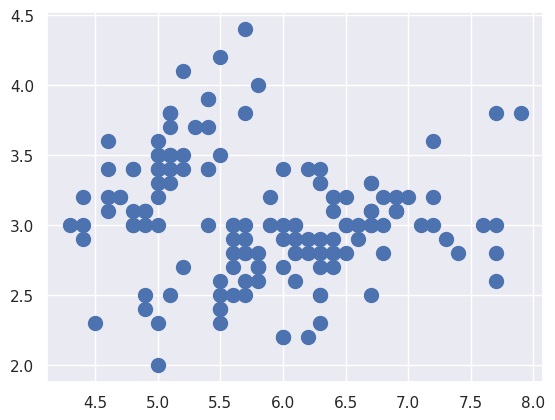

In [31]:
# Plot Data
# Karena data 4 dimensi, maka akan kita coba
# plot cluster berdasarkan Sepal Length dan Sepal Width  saja

plt.scatter(X.iloc[:, 0], X.iloc[:, 1], s = 100)

**Langkah 3 - Membuat Model K-Means**

In [32]:
# Buat Model KMeans
# Kali ini kita coba menggunakan k=2 - anggap saja kita tidak tahu jumlah label ada 3 :)

from sklearn.cluster import KMeans

# Inisiasi obyek KMeans
cl_kmeans = KMeans(n_clusters=2)

# Fit dan predict model
y_kmeans = cl_kmeans.fit_predict(X)

**Langkah 4 - Visualisasi Hasil Clustering**

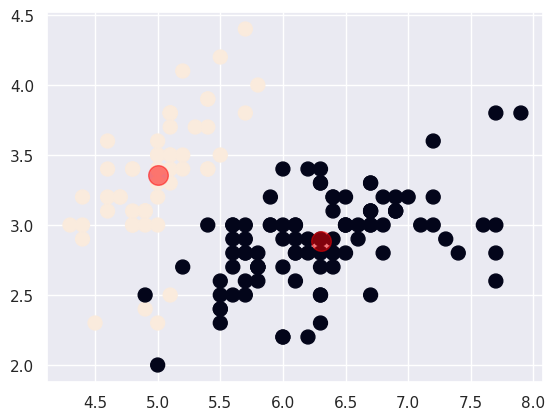

In [33]:
# Plot hasi cluster berdasarkan Sepal Length dan Sepal Width
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], s = 100, c=y_kmeans)

# Plot centroid
centers = cl_kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.5)

**Langkah 5 - Menghitung Nilai SSE**

In [34]:
# Cek Nilai SSE
print(f'Nilai SSE: {cl_kmeans.inertia_}')

Nilai SSE: 152.36870647733915


**Langkah 6 - Implementasi Metode Elbow**

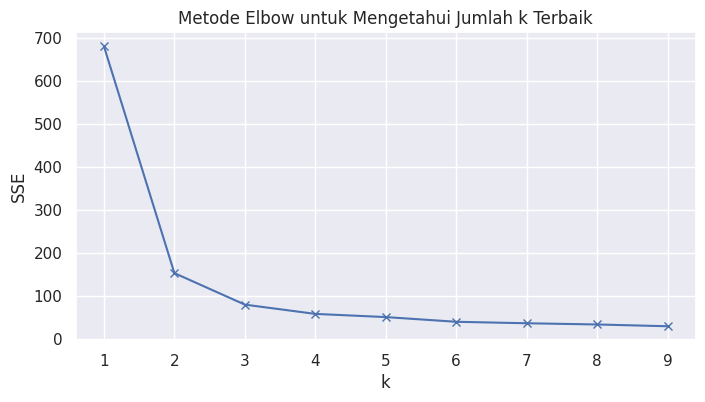

In [35]:
# Implementasi Metode Elbow

# List nilai SSE
sse = []

# Cari k terbaik dari 1-10
K = range(1,10)

# Cek nilai SSE setiap k
for k in K:
 kmeanModel = KMeans(n_clusters=k)
 kmeanModel.fit(X)
 sse.append(kmeanModel.inertia_)


# Plotting the distortions
plt.figure(figsize=(8,4))
plt.plot(K, sse, "bx-")
plt.xlabel("k")
plt.ylabel("SSE")
plt.title("Metode Elbow untuk Mengetahui Jumlah k Terbaik")
plt.show()

**Langkah 7 - Menampilkan Nilai SSE Setiap k**

In [36]:
# Cek Nilai SSE setiap k
for idx, sse_val in enumerate(sse, start=1):
    print(f'k={idx}; SSE={sse_val}')

k=1; SSE=680.8243999999996
k=2; SSE=152.36870647733915
k=3; SSE=78.94084142614601
k=4; SSE=57.317873214285726
k=5; SSE=49.93161386276559
k=6; SSE=38.96478785103787
k=7; SSE=35.52074884135471
k=8; SSE=32.7010139207198
k=9; SSE=28.559214497920376


# **PRAKTIKUM 2**

**Langkah 0 - Import Library**

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()
import numpy as np

## **Pengantar k-Means**

**Langkah 1 - Membuat Dataset Sintetis**

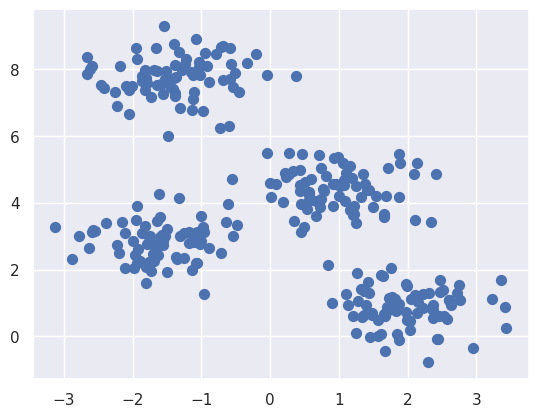

In [38]:
from sklearn.datasets import make_blobs
X, y_true = make_blobs(n_samples=300, centers=4,
                       cluster_std=0.60, random_state=0)
plt.scatter(X[:, 0], X[:, 1], s=50);

**Langkah 2 - Membuat Model K-Means**

In [39]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=4)
kmeans.fit(X)
y_kmeans = kmeans.predict(X)

**Langkah 3 - Visualisasi Hasil Clustering**

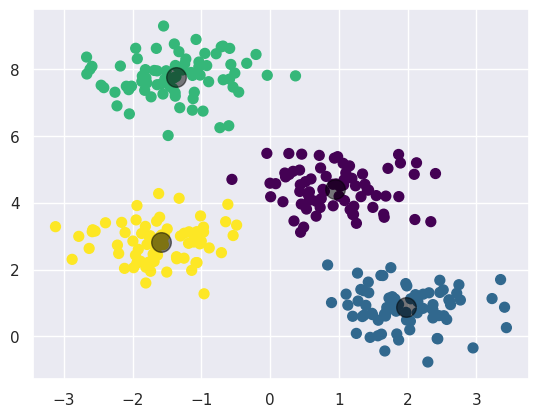

In [40]:
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=50, cmap='viridis')

centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=200, alpha=0.5)

## **Algoritma Expectation-Maximization**

**Langkah 4 - Implementasi K-Means Secara Manual**

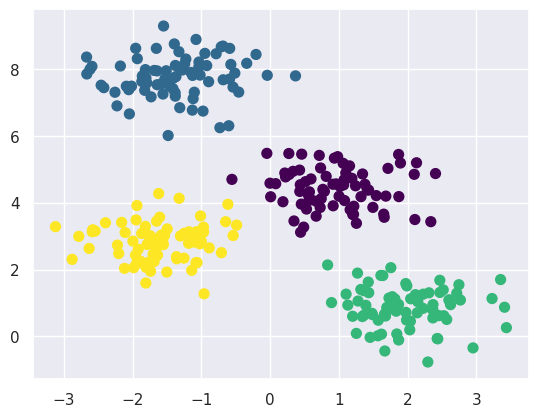

In [41]:
from sklearn.metrics import pairwise_distances_argmin

def find_clusters(X, n_clusters, rseed=2):
    # 1. Randomly choose clusters
    rng = np.random.RandomState(rseed)
    i = rng.permutation(X.shape[0])[:n_clusters]
    centers = X[i]

    while True:
        # 2a. input label center yang baru
        labels = pairwise_distances_argmin(X, centers)

        # 2b. update center dari titik baru
        new_centers = np.array([X[labels == i].mean(0)
                                for i in range(n_clusters)])

        # 2c. cek konvergensi
        if np.all(centers == new_centers):
            break
        centers = new_centers

    return centers, labels

centers, labels = find_clusters(X, 4)
plt.scatter(X[:, 0], X[:, 1], c=labels,s=50, cmap='viridis');

**Langkah 5 - Mengubah Nilai Random Seed**

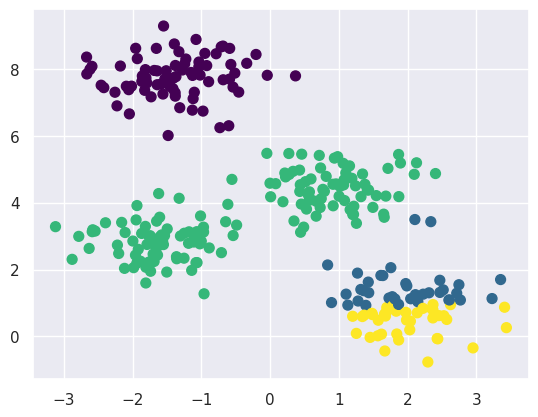

In [42]:
centers, labels = find_clusters(X, 4, rseed=0)
plt.scatter(X[:, 0], X[:, 1], c=labels,s=50, cmap='viridis');

**Langkah 6 - Mengubah Jumlah Cluster**

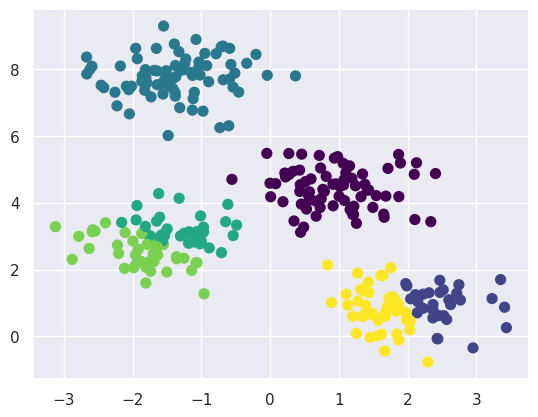

In [43]:
labels = KMeans(6, random_state=0).fit_predict(X)
plt.scatter(X[:, 0], X[:, 1], c=labels, s=50, cmap='viridis');

**Langkah 7 - Membuat Dataset Moon**

In [44]:
from sklearn.datasets import make_moons
X, y = make_moons(200, noise=.05, random_state=0)

**Langkah 8 - Clustering dengan K-Means pada Data Moon**

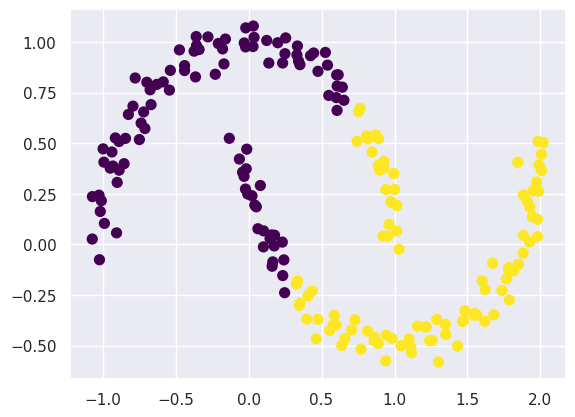

In [45]:
labels = KMeans(2, random_state=0).fit_predict(X)
plt.scatter(X[:, 0], X[:, 1], c=labels,s=50, cmap='viridis');

**Langkah 9 - Clustering dengan Spectral Clustering**

/usr/local/lib/python3.13/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


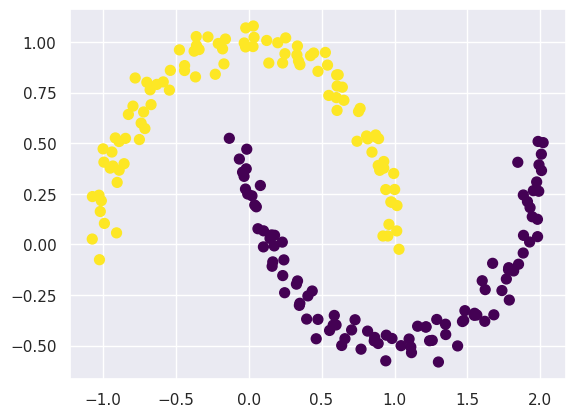

In [46]:
from sklearn.cluster import SpectralClustering
model = SpectralClustering(n_clusters=2, affinity='nearest_neighbors',
                           assign_labels='kmeans')
labels = model.fit_predict(X)
plt.scatter(X[:, 0], X[:, 1], c=labels, s=50, cmap='viridis');

## **Studi Kasus 1 - Karakter Angka**

**Langkah 10 - Memuat Dataset Digits**

In [47]:
from sklearn.datasets import load_digits
digits = load_digits()
digits.data.shape

(1797, 64)

**Langkah 11 - Menerapkan K-Means pada Dataset Digits**

In [48]:
# terapkan K-Means
kmeans = KMeans(n_clusters=10, random_state=0)
clusters = kmeans.fit_predict(digits.data)
kmeans.cluster_centers_.shape

(10, 64)

**Langkah 12 - Menampilkan Centroid Angka**

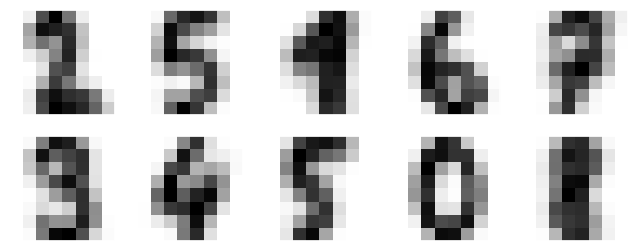

In [49]:
fig, ax = plt.subplots(2, 5, figsize=(8, 3))
centers = kmeans.cluster_centers_.reshape(10, 8, 8)
for axi, center in zip(ax.flat, centers):
    axi.set(xticks=[], yticks=[])
    axi.imshow(center, interpolation='nearest', cmap=plt.cm.binary)

**Langkah 13 - Menentukan Label Cluster**

In [50]:
from scipy.stats import mode

labels = np.zeros_like(clusters)
for i in range(10):
    mask = (clusters == i)
    labels[mask] = mode(digits.target[mask])[0]

**Langkah 14 - Menghitung Akurasi**

In [51]:
from sklearn.metrics import accuracy_score
accuracy_score(digits.target, labels)

0.7440178074568725

**Langkah 15 - Membuat Confusion Matrix**

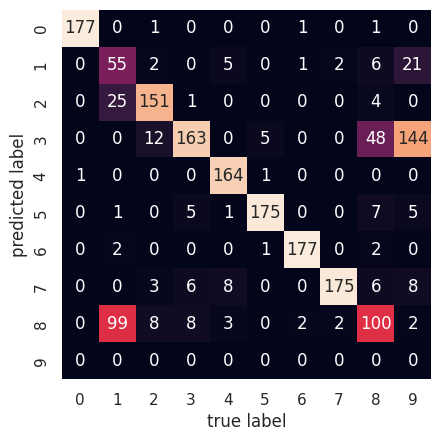

In [52]:
from sklearn.metrics import confusion_matrix
mat = confusion_matrix(digits.target, labels)
sns.heatmap(mat.T, square=True, annot=True, fmt='d', cbar=False,
            xticklabels=digits.target_names,
            yticklabels=digits.target_names)
plt.xlabel('true label')
plt.ylabel('predicted label');

**Langkah 16 - Reduksi Dimensi dengan t-SNE**

In [53]:
from sklearn.manifold import TSNE


tsne = TSNE(n_components=2, init='random', random_state=0)
digits_proj = tsne.fit_transform(digits.data)

# hitung klaster
kmeans = KMeans(n_clusters=10, random_state=0)
clusters = kmeans.fit_predict(digits_proj)

# permutasi label
labels = np.zeros_like(clusters)
for i in range(10):
    mask = (clusters == i)
    labels[mask] = mode(digits.target[mask])[0]

# hitung akurasi
accuracy_score(digits.target, labels)

0.9410127991096272

## **Studi Kasus 2 - Kompresi Citra**

**Langkah 17 - Memuat Gambar Sampel**

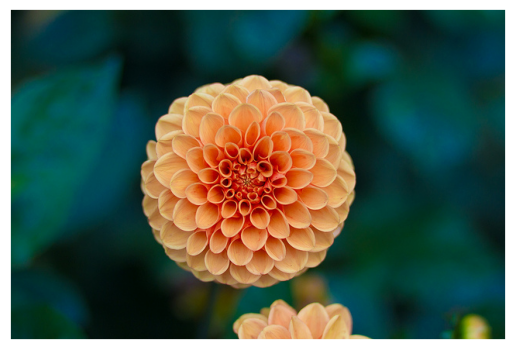

In [54]:
from sklearn.datasets import load_sample_image
flower = load_sample_image("flower.jpg")
ax = plt.axes(xticks=[], yticks=[])
ax.imshow(flower);

**Langkah 18 - Melihat Ukuran Gambar**

In [55]:
flower.shape

(427, 640, 3)

**Langkah 19 - Menyiapkan Data Warna**

In [56]:
data = flower / 255.0
data = data.reshape(427 * 640, 3)
data.shape

(273280, 3)

**Langkah 20 - Membuat Fungsi Visualisasi Warna**

In [57]:
def plot_pixels(data, title, colors=None, N=10000):
    if colors is None:
        colors = data

    # choose a random subset
    rng = np.random.RandomState(0)
    i = rng.permutation(data.shape[0])[:N]
    colors = colors[i]
    R, G, B = data[i].T

    fig, ax = plt.subplots(1, 2, figsize=(16, 6))
    ax[0].scatter(R, G, color=colors, marker='.')
    ax[0].set(xlabel='Red', ylabel='Green', xlim=(0, 1), ylim=(0, 1))

    ax[1].scatter(R, B, color=colors, marker='.')
    ax[1].set(xlabel='Red', ylabel='Blue', xlim=(0, 1), ylim=(0, 1))

    fig.suptitle(title, size=20);

**Langkah 21 - Menampilkan Ruang Warna Asli**

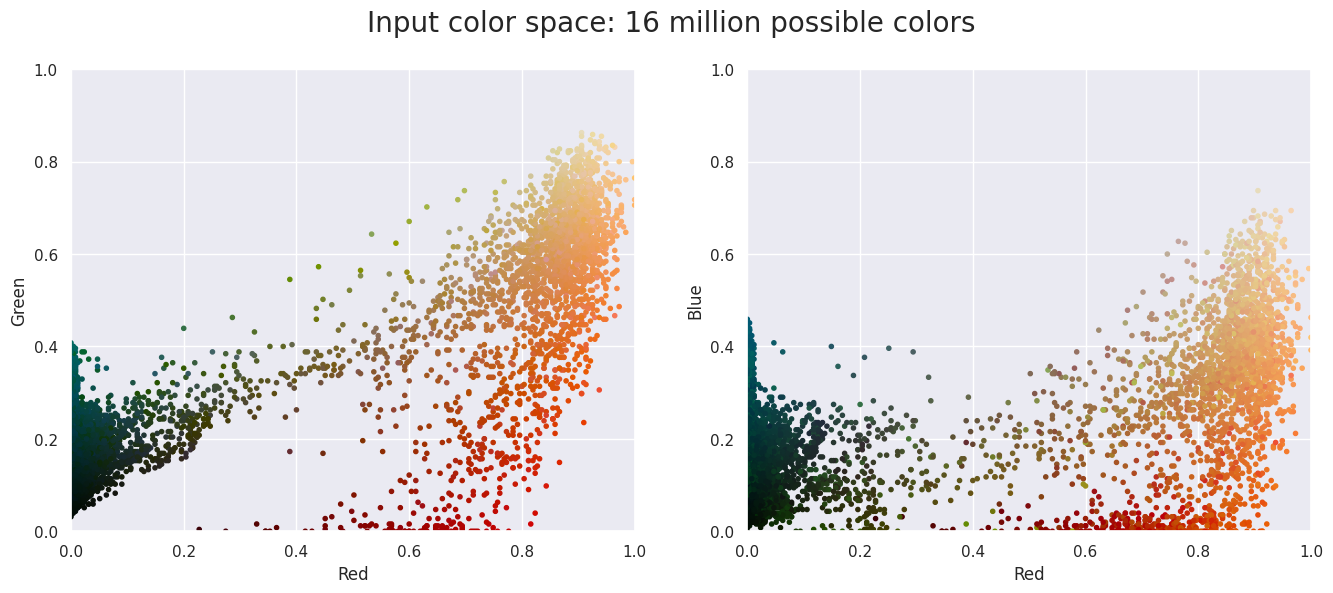

In [58]:
plot_pixels(data, title='Input color space: 16 million possible colors')

**Langkah 22 - Reduksi Warna dengan MiniBatchKMeans**

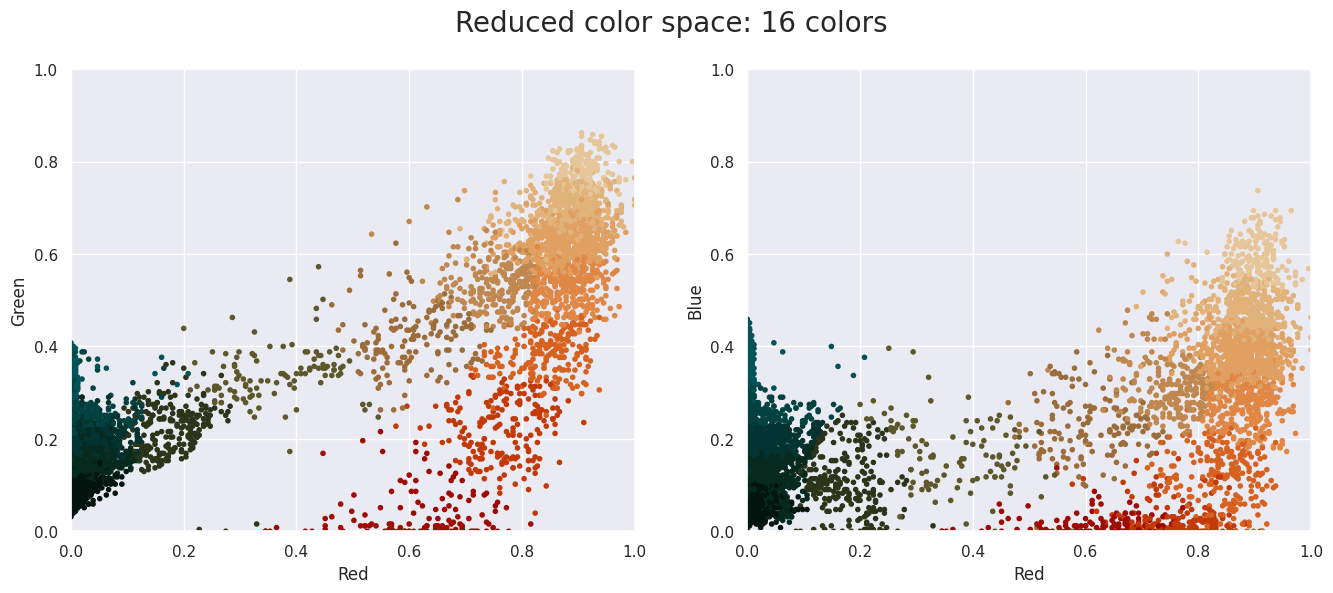

In [59]:
import warnings; warnings.simplefilter('ignore')  # Fix NumPy issues.

from sklearn.cluster import MiniBatchKMeans
kmeans = MiniBatchKMeans(16)
kmeans.fit(data)
new_colors = kmeans.cluster_centers_[kmeans.predict(data)]

plot_pixels(data, colors=new_colors,title="Reduced color space: 16 colors")

**Langkah 23 - Menampilkan Hasil Kompresi Citra**

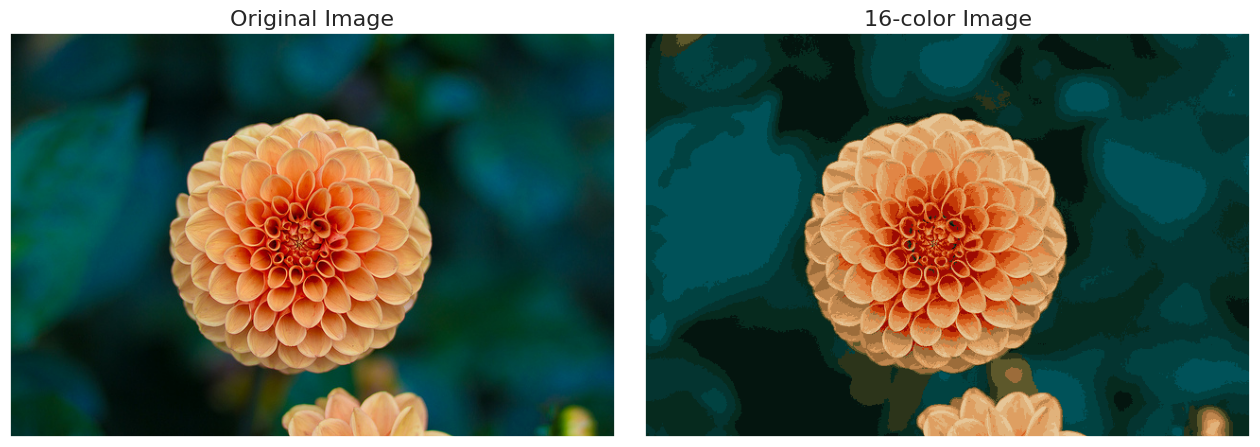

In [60]:
flower_recolored = new_colors.reshape(flower.shape)

fig, ax = plt.subplots(1, 2, figsize=(16, 6),
                       subplot_kw=dict(xticks=[], yticks=[]))
fig.subplots_adjust(wspace=0.05)
ax[0].imshow(flower)
ax[0].set_title('Original Image', size=16)
ax[1].imshow(flower_recolored)
ax[1].set_title('16-color Image', size=16);

# **PRAKTIKUM 3**

**Langkah 0 - Import Library dan Membuat Dataset Sintetis**

In [63]:
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler

centers = [[1, 1], [-1, -1], [1, -1]]
X, labels_true = make_blobs(
    n_samples=750, centers=centers, cluster_std=0.4, random_state=0
)

X = StandardScaler().fit_transform(X)

**Langkah 1 - Visualisasi Dataset**

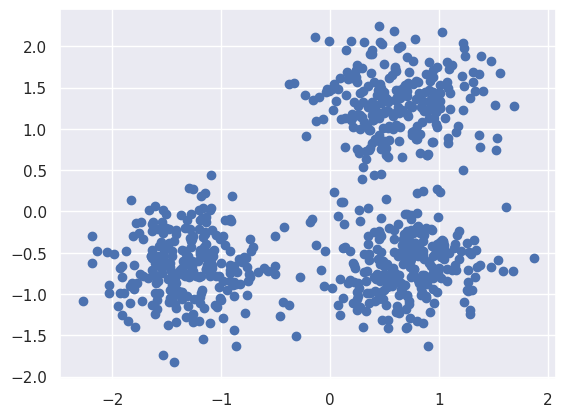

In [66]:
import matplotlib.pyplot as plt

plt.scatter(X[:, 0], X[:, 1])
plt.show()

## **Implementasi DBSCAN**

**Langkah 2 - Membuat Model DBSCAN**

In [71]:
import numpy as np

from sklearn import metrics
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=0.3, min_samples=10).fit(X)
labels = db.labels_

# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

**Langkah 3 - Menampilkan Jumlah Cluster dan Noise**

In [72]:
print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)

Estimated number of clusters: 3
Estimated number of noise points: 18


*  eps = 0.3 → jarak maksimum antar titik untuk dianggap tetangga.
*  min_samples = 10 → jumlah minimum titik dalam radius eps agar dianggap area padat (core sample).
*  Label hasil klasterisasi tersedia di labels. Nilai -1 berarti titik tersebut dianggap noise atau outlier.

## **Evaluasi Kualitas Clustering**

**Langkah 4 - Menghitung Nilai Evaluasi Clustering**

In [74]:
print(f"Homogeneity: {metrics.homogeneity_score(labels_true, labels):.3f}")
print(f"Completeness: {metrics.completeness_score(labels_true, labels):.3f}")
print(f"V-measure: {metrics.v_measure_score(labels_true, labels):.3f}")
print(f"Adjusted Rand Index: {metrics.adjusted_rand_score(labels_true, labels):.3f}")
print(
    "Adjusted Mutual Information:"
    f" {metrics.adjusted_mutual_info_score(labels_true, labels):.3f}"
)
print(f"Silhouette Coefficient: {metrics.silhouette_score(X, labels):.3f}")

Homogeneity: 0.953
Completeness: 0.883
V-measure: 0.917
Adjusted Rand Index: 0.952
Adjusted Mutual Information: 0.916
Silhouette Coefficient: 0.626


*  Homogeneity → apakah tiap klaster hanya berisi satu label asli.
Completeness → apakah semua sampel dengan label asli yang sama masuk ke klaster yang sama.
*  V-measure → rata-rata harmonik dari homogeneity dan completeness.
*  Adjusted Rand Index (ARI) → kesesuaian antara klasterisasi dengan label asli.
*  Adjusted Mutual Information (AMI) → kesamaan informasi antara klasterisasi dengan label asli.
*  Silhouette Coefficient → seberapa baik data dikelompokkan (nilai mendekati 1 berarti bagus, mendekati 0 berarti berada di batas, negatif berarti salah klaster).

## **Visualisasi Hasil DBSCAN**

**Langkah 5 - Menentukan Core Sample dan Label Cluster**

In [75]:
unique_labels = set(labels)
core_samples_mask = np.zeros_like(labels, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True

**Langkah 6 - Menentukan Warna Setiap Cluster**

In [76]:
colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]

**Langkah 7 - Menampilkan Core Sample dan Non Core Sample**

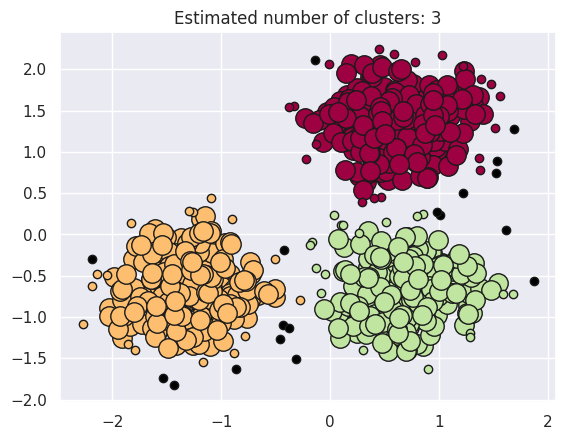

In [81]:
for k, col in zip(unique_labels, colors):
    if k == -1:
        # Black used for noise.
        col = [0, 0, 0, 1]

    class_member_mask = labels == k

    xy = X[class_member_mask & core_samples_mask]
    plt.plot(
        xy[:, 0],
        xy[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=14,
    )
    xy = X[class_member_mask & ~core_samples_mask]
    plt.plot(
        xy[:, 0],
        xy[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=6,
    )


plt.title(f"Estimated number of clusters: {n_clusters_}")
plt.show()

Interpretasi visual:

*   Titik besar berwarna → core samples dalam klaster.
*   Titik kecil berwarna → non-core samples, tetap termasuk klaster.
*   Titik hitam → noise/outlier.

